
=== Processing Fold 1 ===

=== Processing Fold 2 ===

=== Processing Fold 3 ===

=== Processing Fold 4 ===

=== Processing Fold 5 ===

=== Processing Fold 6 ===

=== Processing Fold 7 ===

=== Processing Fold 8 ===

=== Processing Fold 9 ===

=== Processing Fold 10 ===


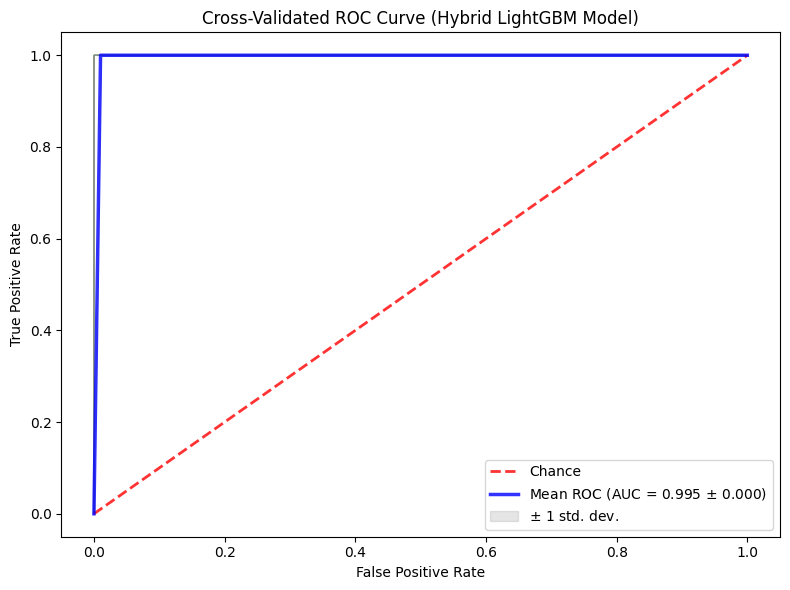


=== Cross-validation Results (mean ± std) ===
      Model      Accuracy     Precision        Recall      F1-score
        cnn 86.55 ± 11.74 78.03 ± 22.81 74.62 ± 20.05 75.99 ± 21.44
transformer  94.87 ± 1.38  96.42 ± 0.50  87.40 ± 3.75  90.95 ± 2.70
     hybrid  99.97 ± 0.01  99.95 ± 0.01  99.97 ± 0.01  99.96 ± 0.01


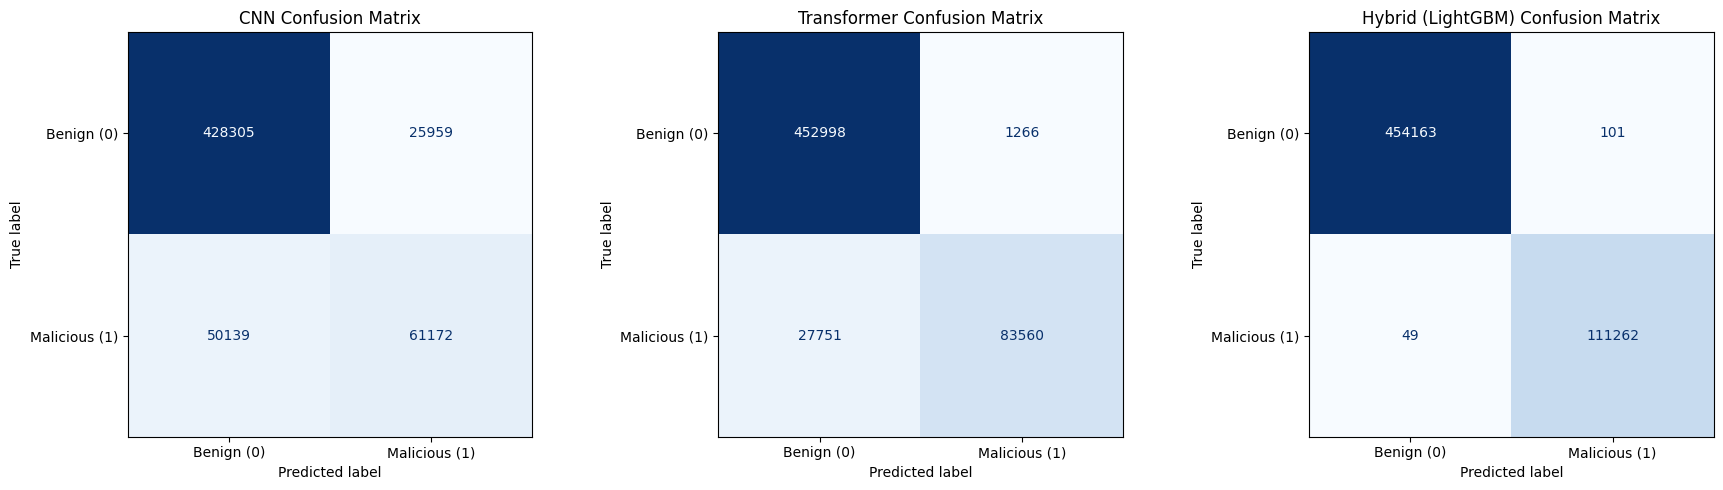


 GLOBAL CLASSIFICATION REPORTS (Across All Folds)

--- CNN ---
               precision    recall  f1-score   support

   Benign (0)     0.8952    0.9429    0.9184    454264
Malicious (1)     0.7021    0.5496    0.6165    111311

     accuracy                         0.8655    565575
    macro avg     0.7986    0.7462    0.7675    565575
 weighted avg     0.8572    0.8655    0.8590    565575


--- Transformer ---
               precision    recall  f1-score   support

   Benign (0)     0.9423    0.9972    0.9690    454264
Malicious (1)     0.9851    0.7507    0.8521    111311

     accuracy                         0.9487    565575
    macro avg     0.9637    0.8740    0.9105    565575
 weighted avg     0.9507    0.9487    0.9460    565575


--- Hybrid (LightGBM) ---
               precision    recall  f1-score   support

   Benign (0)     0.9999    0.9998    0.9998    454264
Malicious (1)     0.9991    0.9996    0.9993    111311

     accuracy                         0.9997    565575


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    classification_report # 🟢 ADDED: classification_report
)
# ================================
# 1️⃣  Paths and setup
# ================================
NUM_FOLDS = 10 
cnn_pred_template = "CNN/inceptionresnet_predictions_fold{}.csv"
transformer_pred_template = "transformers/deit_validation_predictions_fold{}.csv"
fusion_data_path = "fusion_features.csv"

# ================================
# 2️⃣  Load fusion dataset & Clean Features
# ================================
fusion_data = pd.read_csv(fusion_data_path)

label_cols_to_drop = [col for col in fusion_data.columns if 'label' in col.lower()]
X_fusion = fusion_data.drop(columns=label_cols_to_drop)

if 'LineNumber' in X_fusion.columns:
    X_fusion = X_fusion.drop(columns=['LineNumber'])

for col in X_fusion.columns:
    if X_fusion[col].dtype == 'object':
        X_fusion[col] = X_fusion[col].astype('category').cat.codes

true_label_col = next((c for c in fusion_data.columns if "truelabel" in c.lower() or "true_label" in c.lower()), None)
if true_label_col is None:
    raise KeyError("❌ Could not find a TrueLabel column in fusion_features.csv")

# Convert text labels to binary integers (0 and 1)
fusion_data[true_label_col] = fusion_data[true_label_col].apply(
    lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1
)
y_fusion = fusion_data[true_label_col].values

# ================================
# 3️⃣  Containers for metrics & ROC & Predictions
# ================================
metrics = {
    "cnn": {"acc": [], "prec": [], "rec": [], "f1": []},
    "transformer": {"acc": [], "prec": [], "rec": [], "f1": []},
    "hybrid": {"acc": [], "prec": [], "rec": [], "f1": []},
}

# 🟢 ADDED: Track all predictions across folds for the Confusion Matrices
all_preds = {
    "cnn": {"true": [], "pred": []},
    "transformer": {"true": [], "pred": []},
    "hybrid": {"true": [], "pred": []},
}

# --- ROC Trackers ---
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100) # Common FPR axis for interpolating TPRs

fig, ax = plt.subplots(figsize=(8, 6))

# ================================
# 4️⃣  Loop over 10 folds
# ================================
kf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

for k, (train_idx, test_idx) in enumerate(kf.split(X_fusion, y_fusion), 1):
    print(f"\n=== Processing Fold {k} ===")

    # ---- Baselines Predictions ----
    if k<=5 : 
        m = k
    if k>5:
        m = k-5
        
    cnn_df = pd.read_csv(cnn_pred_template.format(m))
    cnn_df.columns = [c.strip().replace(" ", "_").lower() for c in cnn_df.columns]
    true_col = next((c for c in cnn_df.columns if "truelabel" in c or "true_label" in c), None)
    pred_col = next((c for c in cnn_df.columns if "pred" in c), None)
    
    cnn_y_true = cnn_df[true_col].values
    cnn_y_pred = cnn_df[pred_col].values

    trans_df = pd.read_csv(transformer_pred_template.format(m))
    trans_y_true = trans_df["TrueLabel"].values
    trans_y_pred = trans_df["PredLabel"].values 

    label_map = {label: i for i, label in enumerate(np.unique(cnn_y_true))}
    cnn_y_true_num = np.array([label_map[l] for l in cnn_y_true])
    cnn_y_pred_num = np.array([label_map[l] for l in cnn_y_pred])
    trans_y_true_num = np.array([label_map.get(l, 0) for l in trans_y_true])
    trans_y_pred_num = np.array([label_map.get(l, 0) for l in trans_y_pred])

    X_fused = X_fusion.copy()
    X_fused['CNN_Pred'] = cnn_y_pred_num
    X_fused['Transformer_Pred'] = trans_y_pred_num

    X_train, X_test = X_fused.iloc[train_idx], X_fused.iloc[test_idx]
    y_train, y_test = y_fusion[train_idx], y_fusion[test_idx]

    cnn_true_eval, cnn_pred_eval = cnn_y_true_num[test_idx], cnn_y_pred_num[test_idx]
    trans_true_eval, trans_pred_eval = trans_y_true_num[test_idx], trans_y_pred_num[test_idx]

    # ---- Train Hybrid (LightGBM) ----
    lgb_model = lgb.LGBMClassifier(random_state=42 + k, n_estimators=100, verbose=-1)
    lgb_model.fit(X_train, y_train)

    hybrid_y_pred = lgb_model.predict(X_test)
    hybrid_y_true = y_test
    
    # ---- ROC Curve Logic (Hybrid Model) ----
    hybrid_y_proba = lgb_model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(hybrid_y_true, hybrid_y_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    ax.plot(fpr, tpr, alpha=0.3, lw=1)

    # ---- Metrics ----
    def compute_metrics(y_t, y_p):
        return (
            accuracy_score(y_t, y_p),
            precision_score(y_t, y_p, average="macro", zero_division=0),
            recall_score(y_t, y_p, average="macro", zero_division=0),
            f1_score(y_t, y_p, average="macro", zero_division=0),
        )

    for m_name, y_t, y_p in [("cnn", cnn_true_eval, cnn_pred_eval), 
                             ("transformer", trans_true_eval, trans_pred_eval),
                             ("hybrid", hybrid_y_true, hybrid_y_pred)]:
        acc, prec, rec, f1 = compute_metrics(y_t, y_p)
        metrics[m_name]["acc"].append(acc)
        metrics[m_name]["prec"].append(prec)
        metrics[m_name]["rec"].append(rec)
        metrics[m_name]["f1"].append(f1)
        
        # 🟢 ADDED: Accumulate true and predicted labels for the confusion matrix
        all_preds[m_name]["true"].extend(y_t)
        all_preds[m_name]["pred"].extend(y_p)

# ================================
# 5️⃣  Mean ± Std summary & ROC Plot
# ================================
# --- Plot Mean ROC ---
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.3f $\pm$ %0.3f)' % (mean_auc, std_auc),
        lw=2.5, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="Cross-Validated ROC Curve (Hybrid LightGBM Model)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("cv_roc_curve.png", dpi=300)
plt.show()

# --- Print Metrics ---
summary = []
for model_name in ["cnn", "transformer", "hybrid"]:
    summary.append({
        "Model": model_name,
        "Accuracy": f"{np.mean(metrics[model_name]['acc'])*100:.2f} ± {np.std(metrics[model_name]['acc'])*100:.2f}",
        "Precision": f"{np.mean(metrics[model_name]['prec'])*100:.2f} ± {np.std(metrics[model_name]['prec'])*100:.2f}",
        "Recall": f"{np.mean(metrics[model_name]['rec'])*100:.2f} ± {np.std(metrics[model_name]['rec'])*100:.2f}",
        "F1-score": f"{np.mean(metrics[model_name]['f1'])*100:.2f} ± {np.std(metrics[model_name]['f1'])*100:.2f}",
    })

summary_df = pd.DataFrame(summary)
print("\n=== Cross-validation Results (mean ± std) ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("crossval_summary.csv", index=False)


# ================================
# 6️⃣  🟢 ADDED: Confusion Matrices Plotting
# ================================
# Display names for the 3 subplots
model_titles = {"cnn": "CNN", "transformer": "Transformer", "hybrid": "Hybrid (LightGBM)"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, m_name in enumerate(["cnn", "transformer", "hybrid"]):
    # Calculate global confusion matrix for all folds
    cm = confusion_matrix(all_preds[m_name]["true"], all_preds[m_name]["pred"])
    
    # Plot it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malicious (1)"])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"{model_titles[m_name]} Confusion Matrix")

plt.tight_layout()
plt.savefig("cv_confusion_matrices.png", dpi=300)
plt.show()

# ================================
# 7️⃣  🟢 ADDED: Classification Reports
# ================================
print("\n" + "="*50)
print(" GLOBAL CLASSIFICATION REPORTS (Across All Folds)")
print("="*50)

target_names = ["Benign (0)", "Malicious (1)"]

for m_name in ["cnn", "transformer", "hybrid"]:
    print(f"\n--- {model_titles[m_name]} ---")
    
    # Generate the classification report
    report = classification_report(
        all_preds[m_name]["true"], 
        all_preds[m_name]["pred"], 
        target_names=target_names,
        digits=4 # Optional: Shows 4 decimal places instead of the default 2
    )
    print(report)